# FathomNet data visualization starter notebook

This notebook is for the **first pass only**: inspect the dataset structure, preview images, check class balance, look at image sizes, and optionally overlay **bounding boxes** or **masks** if those annotations exist.

It is written to be **robust to different Kaggle/FathomNet directory layouts**, so you can run it first and then adapt the detected columns/paths.

## 0. Context

For your project, this notebook is meant to answer:

1. What files are actually present?
2. Are labels stored in CSV, JSON, or folder names?
3. Do we have **masks** for segmentation, or only image-level / box-level labels?
4. What do underwater images look like in terms of brightness, contrast, and resolution?
5. Is the class distribution badly imbalanced?

After this, the next notebook should build the segmentation data loader and then the U-Net.

In [1]:
import os
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

SEED = 504
random.seed(SEED)
np.random.seed(SEED)

## 1. Inspect the directory structure

In [2]:
ROOT = Path("kaggle")

def print_tree(path, max_depth=2, max_items=25, prefix=""):
    path = Path(path)
    if not path.exists():
        print(f"{path} does not exist")
        return
    if max_depth < 0:
        return
    items = sorted(list(path.iterdir()), key=lambda p: (p.is_file(), p.name.lower()))
    items = items[:max_items]
    for item in items:
        kind = "📁" if item.is_dir() else "📄"
        print(prefix + f"{kind} {item.name}")
        if item.is_dir():
            print_tree(item, max_depth=max_depth-1, max_items=max_items, prefix=prefix + "    ")

print("Top-level contents under /kaggle/input:")
print_tree(ROOT, max_depth=2, max_items=30)

Top-level contents under /kaggle/input:
📁 test_dataset
    📄 000b8e39-7240-49fd-9f50-713edcb28544.png
    📄 0058e081-ab45-4550-a667-5535ffa43ba5.png
    📄 00821ccc-54cb-4c57-8473-f441962cc40e.png
    📄 00b53944-ff7b-417b-ac60-01b1150d2e5f.png
    📄 01ab37a8-2470-47e1-982a-f601c7f66c67.png
    📄 01b7012e-4a7d-4c57-a2d2-62f79debb0f5.png
    📄 02352bf2-b507-40f7-9f61-9252f962bfcd.png
    📄 0240e8e8-4afb-46c4-90b9-85bcafb53ed6.png
    📄 024e064e-243e-47b7-9726-00a192071174.png
    📄 029c85e1-6a3c-4a08-bef8-fecfdf97ff86.png
    📄 03c5b1f6-f0a3-4e1e-93be-0df54ca28350.png
    📄 03d05d06-0475-46ab-a96a-cad5b257ea2a.png
    📄 03e435c9-3deb-431e-91dd-82e3aadd95b2.png
    📄 03f71fe5-a743-4e56-85a7-96189bb1e1cf.png
    📄 03fcbaf3-cb8f-40c1-96fa-90d36e3a93df.png
    📄 0408e41f-1960-4670-8722-b3c6c1bf5934.png
    📄 041984f0-997f-4d80-9e64-1d90317ee4d4.png
    📄 0440f024-1750-4ef8-af02-d538227580e5.png
    📄 04e1ff59-2f6e-4a6d-bb1d-e21b6f902844.png
    📄 04e5205b-168f-47a7-a9bc-000e10a8cc74.png
    📄

## 2. Find likely metadata files and image files

In [3]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
META_EXTS = {".csv", ".json", ".txt"}

all_files = [p for p in ROOT.rglob("*") if p.is_file()]
image_files = [p for p in all_files if p.suffix.lower() in IMAGE_EXTS]
meta_files = [p for p in all_files if p.suffix.lower() in META_EXTS]

print(f"Found {len(image_files):,} image files")
print(f"Found {len(meta_files):,} metadata/text files\n")

print("Some metadata files:")
for p in meta_files[:30]:
    print(" -", p)

print("\nSome image files:")
for p in image_files[:20]:
    print(" -", p)

Found 8,019 image files
Found 0 metadata/text files

Some metadata files:

Some image files:
 - kaggle\test_dataset\000b8e39-7240-49fd-9f50-713edcb28544.png
 - kaggle\test_dataset\0058e081-ab45-4550-a667-5535ffa43ba5.png
 - kaggle\test_dataset\00821ccc-54cb-4c57-8473-f441962cc40e.png
 - kaggle\test_dataset\00b53944-ff7b-417b-ac60-01b1150d2e5f.png
 - kaggle\test_dataset\01ab37a8-2470-47e1-982a-f601c7f66c67.png
 - kaggle\test_dataset\01b7012e-4a7d-4c57-a2d2-62f79debb0f5.png
 - kaggle\test_dataset\02352bf2-b507-40f7-9f61-9252f962bfcd.png
 - kaggle\test_dataset\0240e8e8-4afb-46c4-90b9-85bcafb53ed6.png
 - kaggle\test_dataset\024e064e-243e-47b7-9726-00a192071174.png
 - kaggle\test_dataset\029c85e1-6a3c-4a08-bef8-fecfdf97ff86.png
 - kaggle\test_dataset\03c5b1f6-f0a3-4e1e-93be-0df54ca28350.png
 - kaggle\test_dataset\03d05d06-0475-46ab-a96a-cad5b257ea2a.png
 - kaggle\test_dataset\03e435c9-3deb-431e-91dd-82e3aadd95b2.png
 - kaggle\test_dataset\03f71fe5-a743-4e56-85a7-96189bb1e1cf.png
 - kaggle\t

## 3. Load CSV files and inspect columns

In [4]:
csv_files = [p for p in meta_files if p.suffix.lower() == ".csv"]
csv_dfs = {}

for csv_path in csv_files[:20]:
    try:
        df = pd.read_csv(csv_path)
        csv_dfs[str(csv_path)] = df
        print(f"\n=== {csv_path} ===")
        print(f"shape = {df.shape}")
        print("columns =", list(df.columns))
        display(df.head(3))
    except Exception as e:
        print(f"Could not read {csv_path}: {e}")

## 4. Helper: guess useful columns

This is heuristic only. It tries to locate:
- image path / filename columns
- class label columns
- bbox columns
- mask path columns

In [5]:
def guess_columns(df):
    cols = [c.lower() for c in df.columns]
    original = list(df.columns)
    out = {
        "image_cols": [],
        "label_cols": [],
        "bbox_cols": [],
        "mask_cols": [],
    }

    for c0, c in zip(original, cols):
        if any(k in c for k in ["image", "img", "file", "filename", "path", "url"]):
            out["image_cols"].append(c0)
        if any(k in c for k in ["label", "class", "concept", "category", "supercategory", "target", "species"]):
            out["label_cols"].append(c0)
        if c in {"x", "y", "w", "h", "width", "height", "xmin", "ymin", "xmax", "ymax"}:
            out["bbox_cols"].append(c0)
        if "mask" in c or "rle" in c:
            out["mask_cols"].append(c0)
    return out

for name, df in csv_dfs.items():
    print("\n", name)
    print(guess_columns(df))

## 5. Pick the main metadata table manually if needed

In [6]:
# Try to auto-pick a likely annotation table.
candidate_tables = []
for name, df in csv_dfs.items():
    g = guess_columns(df)
    score = 2 * len(g["label_cols"]) + len(g["image_cols"]) + len(g["bbox_cols"]) + len(g["mask_cols"])
    candidate_tables.append((score, name))

candidate_tables = sorted(candidate_tables, reverse=True)
candidate_tables[:10]

[]

In [7]:
main_df = None
main_name = None

if candidate_tables:
    _, main_name = candidate_tables[0]
    main_df = csv_dfs[main_name].copy()
    print("Auto-selected table:", main_name)
    print("Shape:", main_df.shape)
    display(main_df.head())
else:
    print("No CSV tables detected. You may need to work directly from folders or JSON.")

No CSV tables detected. You may need to work directly from folders or JSON.


## 6. Class distribution

In [8]:
def first_existing(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

if main_df is not None:
    label_col = first_existing(
        ["label", "class", "concept", "category", "supercategory", "species", "target"],
        main_df.columns
    )

    if label_col is None:
        # fallback: use first guessed label col
        guessed = guess_columns(main_df)["label_cols"]
        label_col = guessed[0] if guessed else None

    print("Chosen label column:", label_col)

    if label_col is not None:
        vc = main_df[label_col].astype(str).value_counts().head(30)
        display(vc.to_frame("count"))

        plt.figure(figsize=(14, 6))
        vc.plot(kind="bar")
        plt.title(f"Top classes in {label_col}")
        plt.ylabel("Count")
        plt.xticks(rotation=60, ha="right")
        plt.show()
    else:
        print("No label-like column found automatically.")

## 7. Resolve image paths

In [9]:
def find_existing_image_col(df):
    guesses = guess_columns(df)["image_cols"]
    for c in guesses:
        if c in df.columns:
            return c
    return None

def resolve_image_path(val):
    if pd.isna(val):
        return None
    val = str(val)
    p = Path(val)
    if p.exists():
        return p
    # look under /kaggle/input recursively by filename
    matches = list(ROOT.rglob(p.name))
    if matches:
        return matches[0]
    return None

resolved_image_col = None
if main_df is not None:
    image_col = find_existing_image_col(main_df)
    print("Chosen image/path column:", image_col)

    if image_col is not None:
        main_df["_resolved_image"] = main_df[image_col].apply(resolve_image_path)
        resolved_image_col = "_resolved_image"
        print("Resolved images:", main_df["_resolved_image"].notna().sum(), "of", len(main_df))
        display(main_df[[image_col, "_resolved_image"]].head(10))
    else:
        print("No image/path column found in metadata. Will sample from image folders directly.")

## 8. Show random image samples

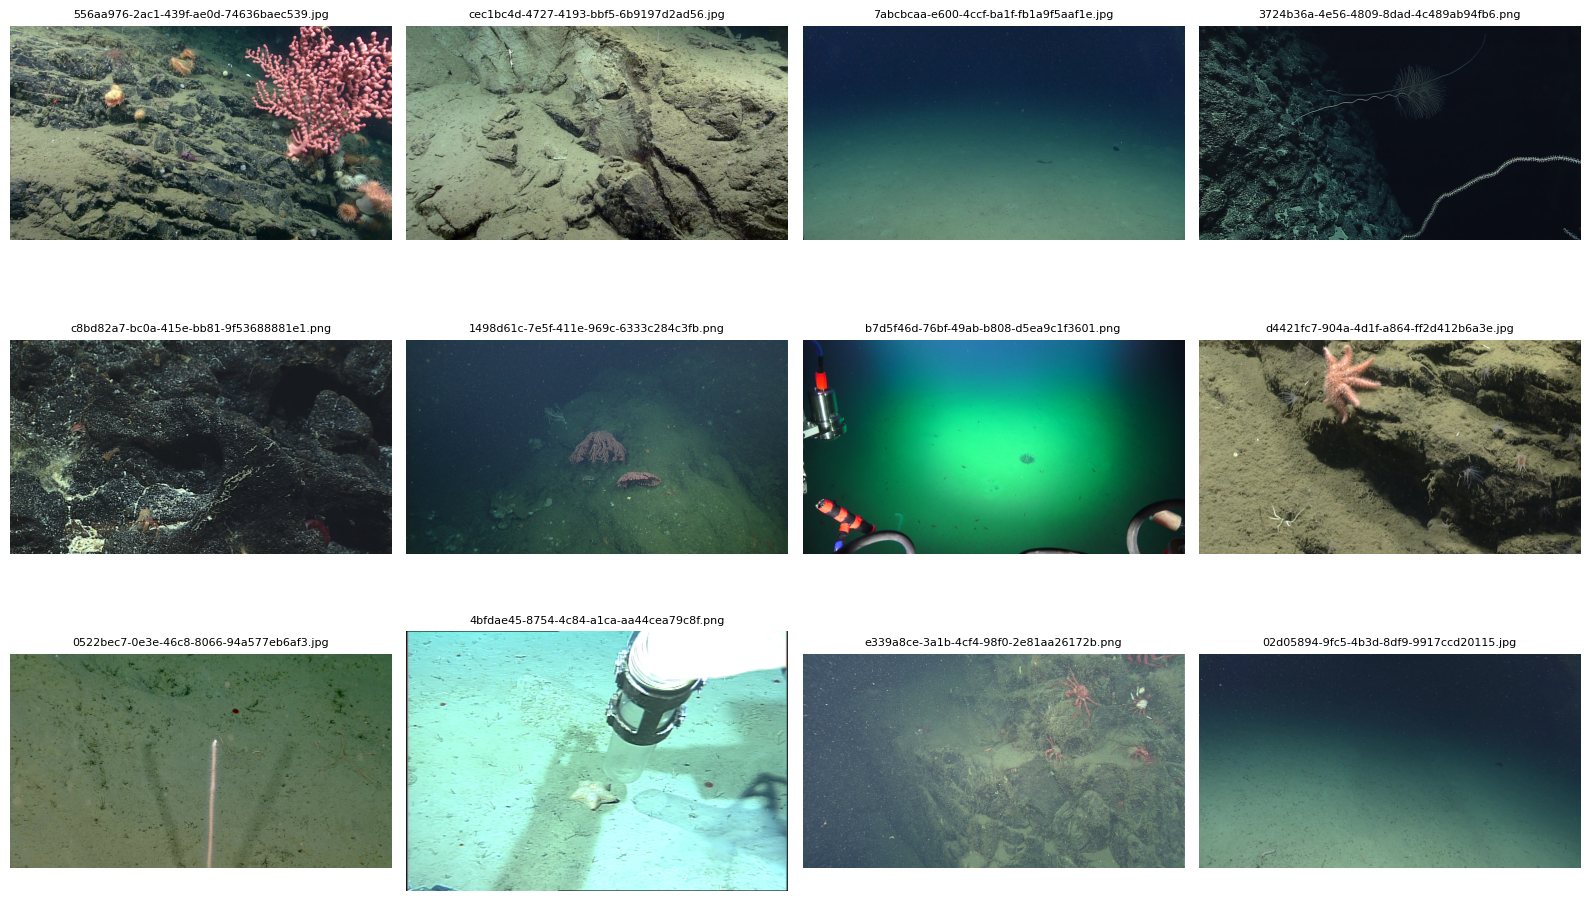

In [10]:
from PIL import Image, UnidentifiedImageError

def load_img(path):
    try:
        with Image.open(path) as img:
            return img.convert("RGB")
    except (UnidentifiedImageError, OSError) as e:
        print(f"Skipping unreadable image: {path} | {e}")
        return None

def show_image_grid(paths, titles=None, cols=4, figsize=(16, 10)):
    import math
    import matplotlib.pyplot as plt

    valid = []
    valid_titles = []

    for i, p in enumerate(paths):
        img = load_img(p)
        if img is not None:
            valid.append(img)
            valid_titles.append(titles[i] if titles is not None else str(p))

    if not valid:
        print("No readable images found.")
        return

    rows = math.ceil(len(valid) / cols)
    plt.figure(figsize=figsize)

    for i, img in enumerate(valid):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(valid_titles[i], fontsize=8)

    plt.tight_layout()
    plt.show()

sample_paths = []
sample_titles = []

if main_df is not None and resolved_image_col is not None and main_df[resolved_image_col].notna().any():
    tmp = main_df[main_df[resolved_image_col].notna()].sample(min(12, main_df[resolved_image_col].notna().sum()), random_state=SEED)
    sample_paths = list(tmp[resolved_image_col])
    title_col = label_col if "label_col" in globals() and label_col in tmp.columns else None
    sample_titles = list(tmp[title_col].astype(str)) if title_col else [p.name for p in sample_paths]
else:
    sample_paths = random.sample(image_files, min(12, len(image_files)))
    sample_titles = [p.name for p in sample_paths]

show_image_grid(sample_paths, sample_titles, cols=4, figsize=(16, 10))


## 9. Image size / aspect ratio distribution

,path,width,height,aspect_ratio
0,kaggle\test_dataset\000b8e39-7240-49fd-9f50-71...,1920,1080,1.777778
1,kaggle\test_dataset\0058e081-ab45-4550-a667-55...,720,486,1.481481
2,kaggle\test_dataset\00821ccc-54cb-4c57-8473-f4...,1920,1080,1.777778
3,kaggle\test_dataset\00b53944-ff7b-417b-ac60-01...,1920,1080,1.777778
4,kaggle\test_dataset\01ab37a8-2470-47e1-982a-f6...,1920,1080,1.777778


Num usable images: 2000


,width,height,aspect_ratio
count,2000.000000,2000.000000,2000.000000
mean,2017.616500,1143.345500,1.746191
std,766.461486,416.735282,0.093339
min,640.000000,366.000000,1.316872
25%,1920.000000,1080.000000,1.777778
50%,1920.000000,1080.000000,1.777778
75%,1920.000000,1080.000000,1.777778
max,3840.000000,2160.000000,1.967213


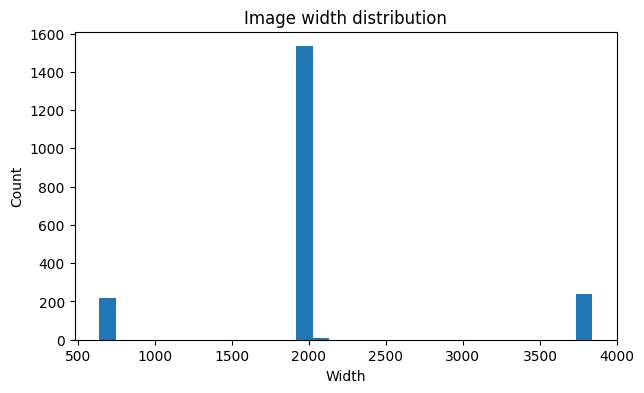

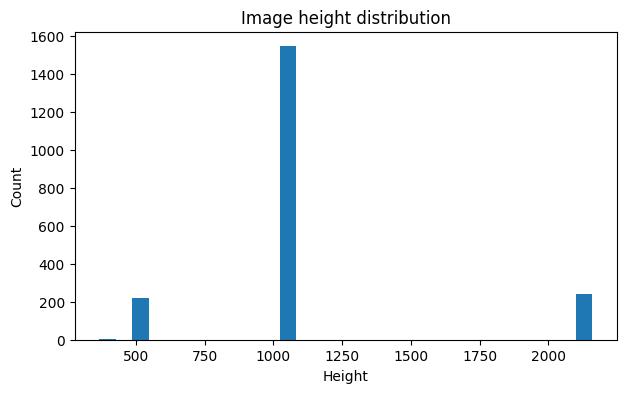

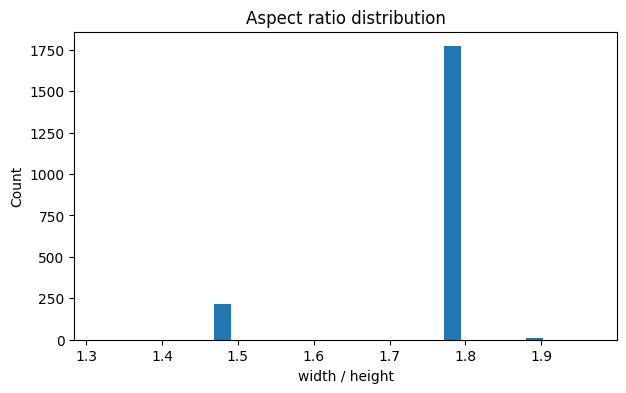

In [11]:
paths_for_stats = []

if main_df is not None and resolved_image_col is not None:
    paths_for_stats = [p for p in main_df[resolved_image_col].dropna().tolist()[:2000]]
else:
    paths_for_stats = image_files[:2000]

sizes = []
for p in paths_for_stats:
    try:
        with Image.open(p) as img:
            w, h = img.size
        sizes.append((p, w, h, w / h))
    except Exception:
        pass

size_df = pd.DataFrame(sizes, columns=["path", "width", "height", "aspect_ratio"])
display(size_df.head())

print("Num usable images:", len(size_df))
display(size_df[["width", "height", "aspect_ratio"]].describe())

plt.figure(figsize=(7, 4))
plt.hist(size_df["width"], bins=30)
plt.title("Image width distribution")
plt.xlabel("Width")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(size_df["height"], bins=30)
plt.title("Image height distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(size_df["aspect_ratio"], bins=30)
plt.title("Aspect ratio distribution")
plt.xlabel("width / height")
plt.ylabel("Count")
plt.show()

## 10. Brightness / contrast inspection for underwater images

,brightness,contrast
count,500.000000,500.000000
mean,0.355187,0.093443
std,0.112959,0.061979
min,0.078944,0.015458
25%,0.271048,0.041553
50%,0.351283,0.078160
75%,0.426529,0.130557
max,0.778634,0.295060


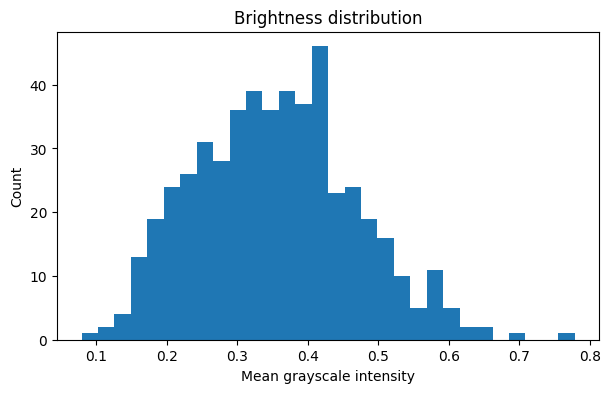

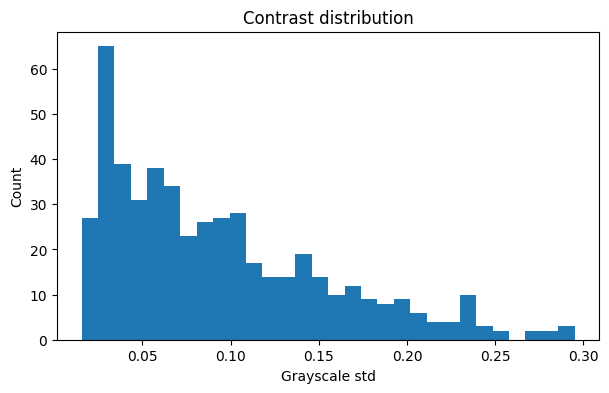

In [12]:
def brightness_contrast(img):
    arr = np.asarray(img).astype(np.float32) / 255.0
    gray = arr.mean(axis=2)
    return gray.mean(), gray.std()

sample_for_bc = paths_for_stats[:500]
bc = []
for p in sample_for_bc:
    try:
        img = load_img(p)
        b, c = brightness_contrast(img)
        bc.append((str(p), b, c))
    except Exception:
        pass

bc_df = pd.DataFrame(bc, columns=["path", "brightness", "contrast"])
display(bc_df.describe())

plt.figure(figsize=(7, 4))
plt.hist(bc_df["brightness"], bins=30)
plt.title("Brightness distribution")
plt.xlabel("Mean grayscale intensity")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(bc_df["contrast"], bins=30)
plt.title("Contrast distribution")
plt.xlabel("Grayscale std")
plt.ylabel("Count")
plt.show()

## 11. Bounding-box visualization

This only works if your table has image + bbox columns.
Supported formats:
- `(x, y, width, height)`
- `(xmin, ymin, xmax, ymax)`

In [13]:
bbox_candidates = ["x", "y", "width", "height", "w", "h", "xmin", "ymin", "xmax", "ymax"]
if main_df is not None:
    bbox_cols_present = [c for c in bbox_candidates if c in main_df.columns]
    print("BBox-related columns found:", bbox_cols_present)

In [14]:
def draw_bbox(img, row, label_text=None):
    img = img.copy()
    draw = ImageDraw.Draw(img)

    cols = set(row.index)

    if {"x", "y", "width", "height"}.issubset(cols):
        x1 = float(row["x"])
        y1 = float(row["y"])
        x2 = x1 + float(row["width"])
        y2 = y1 + float(row["height"])
    elif {"x", "y", "w", "h"}.issubset(cols):
        x1 = float(row["x"])
        y1 = float(row["y"])
        x2 = x1 + float(row["w"])
        y2 = y1 + float(row["h"])
    elif {"xmin", "ymin", "xmax", "ymax"}.issubset(cols):
        x1 = float(row["xmin"])
        y1 = float(row["ymin"])
        x2 = float(row["xmax"])
        y2 = float(row["ymax"])
    else:
        return img

    draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
    if label_text:
        draw.text((x1, max(0, y1 - 12)), str(label_text), fill="red")
    return img

if main_df is not None and resolved_image_col is not None:
    bbox_demo = main_df.dropna(subset=[resolved_image_col]).copy()

    has_xywh = {"x", "y", "width", "height"}.issubset(bbox_demo.columns) or {"x", "y", "w", "h"}.issubset(bbox_demo.columns)
    has_xyxy = {"xmin", "ymin", "xmax", "ymax"}.issubset(bbox_demo.columns)

    if has_xywh or has_xyxy:
        bbox_demo = bbox_demo.sample(min(8, len(bbox_demo)), random_state=SEED)

        plt.figure(figsize=(16, 8))
        for i, (_, row) in enumerate(bbox_demo.iterrows(), start=1):
            plt.subplot(2, 4, i)
            try:
                img = load_img(row[resolved_image_col])
                txt = row[label_col] if "label_col" in globals() and label_col in row.index else None
                img = draw_bbox(img, row, txt)
                plt.imshow(img)
                plt.axis("off")
            except Exception as e:
                plt.text(0.1, 0.5, f"Error: {e}")
                plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("No recognizable bbox format found.")

## 12. Mask visualization

If you have segmentation masks, set:
- `MASK_IMAGE_DIR` if masks are stored as images
- or adapt this section for RLE/polygon masks

In [15]:
MASK_IMAGE_DIR = None  # Example: Path('/kaggle/input/your-dataset/masks')

def find_mask_files():
    if MASK_IMAGE_DIR is not None and Path(MASK_IMAGE_DIR).exists():
        mask_files = [p for p in Path(MASK_IMAGE_DIR).rglob("*") if p.suffix.lower() in IMAGE_EXTS]
        return mask_files
    return []

mask_files = find_mask_files()
print("Detected mask files:", len(mask_files))
mask_files[:10]

Detected mask files: 0


[]

In [16]:
def overlay_mask_on_image(img, mask, alpha=0.4):
    img_arr = np.asarray(img).astype(np.float32)
    mask_arr = np.asarray(mask)

    if mask_arr.ndim == 3:
        mask_arr = mask_arr[..., 0]

    mask_bin = (mask_arr > 0).astype(np.float32)

    overlay = img_arr.copy()
    overlay[..., 1] = np.maximum(overlay[..., 1], mask_bin * 255)  # green highlight

    out = img_arr * (1 - alpha * mask_bin[..., None]) + overlay * (alpha * mask_bin[..., None])
    return np.clip(out / 255.0, 0, 1)

if mask_files:
    demo_masks = random.sample(mask_files, min(6, len(mask_files)))
    plt.figure(figsize=(16, 8))
    for i, mp in enumerate(demo_masks, start=1):
        plt.subplot(2, 3, i)
        try:
            # assumes same filename stem for image and mask; adapt if needed
            stem = mp.stem
            possible_imgs = [p for p in image_files if p.stem == stem]
            if not possible_imgs:
                plt.text(0.1, 0.5, f"No matching image for {mp.name}")
                plt.axis("off")
                continue
            ip = possible_imgs[0]
            img = load_img(ip)
            mask = Image.open(mp)
            vis = overlay_mask_on_image(img, mask)
            plt.imshow(vis)
            plt.title(stem)
            plt.axis("off")
        except Exception as e:
            plt.text(0.1, 0.5, f"Error: {e}")
            plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No mask directory configured yet.")

No mask directory configured yet.


## 13. What to write down from this notebook

Once you run this, record:

- exact image directory
- exact annotation file
- exact label column
- whether masks exist
- most common resolutions
- class imbalance severity
- whether underwater images are mostly dark / low contrast
- whether bbox-only supervision is available

That gives you the correct next step:
- **bbox/classification only** → not enough for plain U-Net segmentation training
- **mask supervision exists** → build segmentation dataset loader next

## 14. Suggested next notebook

After you run this notebook, the next one should do:

1. Dataset class for `(image, mask)`
2. resizing / normalization
3. train-val split
4. very small U-Net sanity check
5. qualitative prediction plots
6. IoU / Dice